<a href="https://colab.research.google.com/github/muskan2109/FML_Practicals/blob/main/Task8_EE510.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Hierarchical clustering**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage


In [6]:
file = "wireless_signal_hierarchical_dataset.csv"

In [4]:
data = pd.read_csv(file)

In [5]:
if len(data.columns) == 1:

    print("Single column detected. Fixing CSV format...")

    data = data.iloc[:,0].str.split(
        ",",
        expand=True
    )


Single column detected. Fixing CSV format...


In [7]:
    data.columns = [
        "RSSI",
        "RSRP",
        "RSRQ",
        "SNR",
        "Latency",
        "Packet_Loss"
    ]


In [8]:
print("\nDataset Preview:")
print(data.head())


print("\nDataset Columns:")
print(data.columns)



Dataset Preview:
  RSSI RSRP RSRQ SNR Latency Packet_Loss
0  -45  -75   -5  30      10           1
1  -48  -78   -6  28      12           1
2  -50  -80   -7  27      15           2
3  -52  -82   -8  25      18           2
4  -55  -85   -9  23      20           3

Dataset Columns:
Index(['RSSI', 'RSRP', 'RSRQ', 'SNR', 'Latency', 'Packet_Loss'], dtype='object')


In [9]:
for col in data.columns:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )


data.dropna(inplace=True)
print("\nMissing Values:")
print(data.isnull().sum())



X = data[
    [
        "RSSI",
        "RSRP",
        "RSRQ",
        "SNR",
        "Latency",
        "Packet_Loss"
    ]
]




Missing Values:
RSSI           0
RSRP           0
RSRQ           0
SNR            0
Latency        0
Packet_Loss    0
dtype: int64


{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [45.0, 45.0, 55.0, 55.0],
  [35.0, 35.0, 50.0, 50.0],
  [65.0, 65.0, 75.0, 75.0],
  [42.5, 42.5, 70.0, 70.0],
  [12.5, 12.5, 56.25, 56.25],
  [85.0, 85.0, 95.0, 95.0],
  [105.0, 105.0, 115.0, 115.0],
  [90.0, 90.0, 110.0, 110.0],
  [125.0, 125.0, 135.0, 135.0],
  [155.0, 155.0, 165.0, 165.0],
  [145.0, 145.0, 160.0, 160.0],
  [130.0, 130.0, 152.5, 152.5],
  [100.0, 100.0, 141.25, 141.25],
  [195.0, 195.0, 205.0, 205.0],
  [185.0, 185.0, 200.0, 200.0],
  [175.0, 175.0, 192.5, 192.5],
  [225.0, 225.0, 235.0, 235.0],
  [215.0, 215.0, 230.0, 230.0],
  [255.0, 255.0, 265.0, 265.0],
  [245.0, 245.0, 260.0, 260.0],
  [275.0, 275.0, 285.0, 285.0],
  [252.5, 252.5, 280.0, 280.0],
  [222.5, 222.5, 266.25, 266.25],
  [183.75, 183.75, 244.375, 244.375],
  [120.625, 120.625, 214.0625, 214.0625],
  [34.375, 34.375, 167.34375, 167.34375]],
 'dcoord': [[0.0,
   np.float64(0.43034413789480574),
   np.float64(0.43034413789480574),
   0.0]

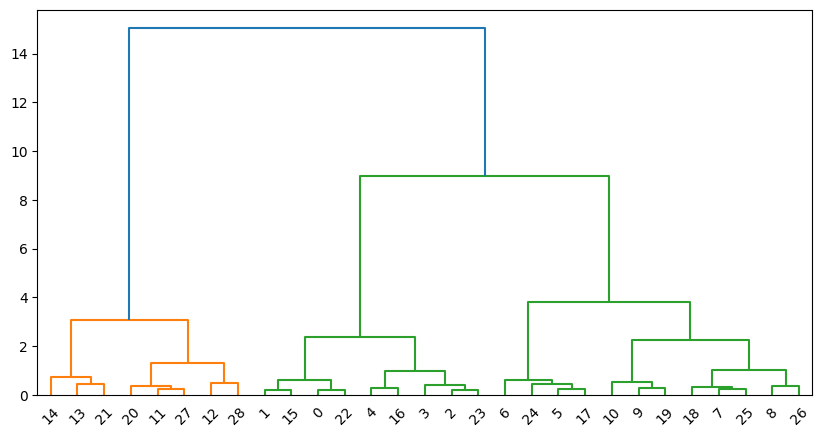

In [11]:
scaler = StandardScaler()


X_scaled = scaler.fit_transform(X)




plt.figure(figsize=(10,5))


linked = linkage(
    X_scaled,
    method="ward"
)
dendrogram(linked)

Text(0, 0.5, 'Distance')

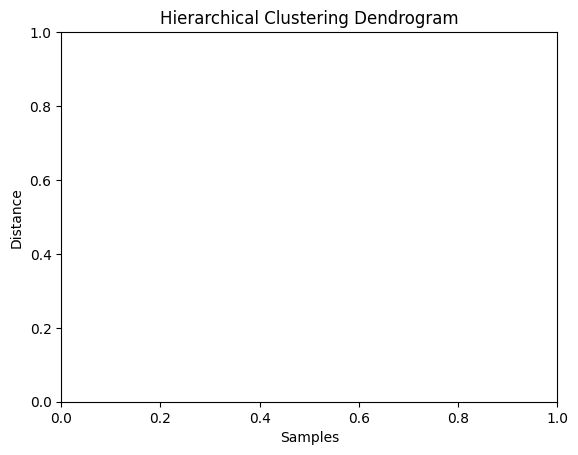

In [12]:
plt.title(
    "Hierarchical Clustering Dendrogram"
)


plt.xlabel(
    "Samples"
)


plt.ylabel(
    "Distance"
)



In [14]:
plt.show()


model = AgglomerativeClustering(

    n_clusters=3,

    linkage="ward"

)
data["Cluster"] = model.fit_predict(
    X_scaled
)


In [16]:
print("\nCluster Count:")

print(
    data["Cluster"].value_counts()
)
cluster_rssi = data.groupby(
    "Cluster"
)["RSSI"].mean()
print("\nAverage RSSI:")
print(cluster_rssi)



sorted_clusters = cluster_rssi.sort_values(
    ascending=False
)




Cluster Count:
Cluster
0    12
2     9
1     8
Name: count, dtype: int64

Average RSSI:
Cluster
0   -63.500000
1   -76.000000
2   -49.777778
Name: RSSI, dtype: float64


In [17]:
quality = {

    sorted_clusters.index[0] : "Good",

    sorted_clusters.index[1] : "Medium",

    sorted_clusters.index[2] : "Poor"

}


In [19]:
data["Signal_Quality"] = data["Cluster"].map(
    quality
)



print("\nFinal Classification:")

print(

    data[
        [
            "RSSI",
            "RSRP",
            "SNR",
            "Cluster",
            "Signal_Quality"
        ]
    ]
)


Final Classification:
    RSSI  RSRP  SNR  Cluster Signal_Quality
0    -45   -75   30        2           Good
1    -48   -78   28        2           Good
2    -50   -80   27        2           Good
3    -52   -82   25        2           Good
4    -55   -85   23        2           Good
5    -58   -88   20        0         Medium
6    -60   -90   18        0         Medium
7    -62   -92   16        0         Medium
8    -65   -95   14        0         Medium
9    -68   -98   12        0         Medium
10   -70  -100   10        0         Medium
11   -72  -102    8        1           Poor
12   -75  -105    6        1           Poor
13   -78  -108    5        1           Poor
14   -80  -110    3        1           Poor
15   -47   -77   29        2           Good
16   -54   -84   24        2           Good
17   -59   -89   19        0         Medium
18   -64   -94   15        0         Medium
19   -69   -99   11        0         Medium
20   -74  -104    7        1           Poor
21   -79 

In [20]:
pca = PCA(
    n_components=2
)


X_pca = pca.fit_transform(
    X_scaled
)


<Axes: >

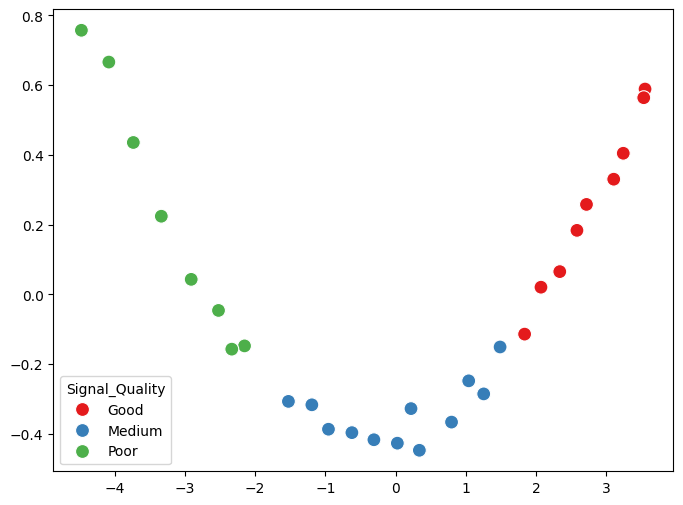

In [21]:
plt.figure(figsize=(8,6))


sns.scatterplot(

    x=X_pca[:,0],

    y=X_pca[:,1],

    hue=data["Signal_Quality"],

    palette="Set1",

    s=100

)


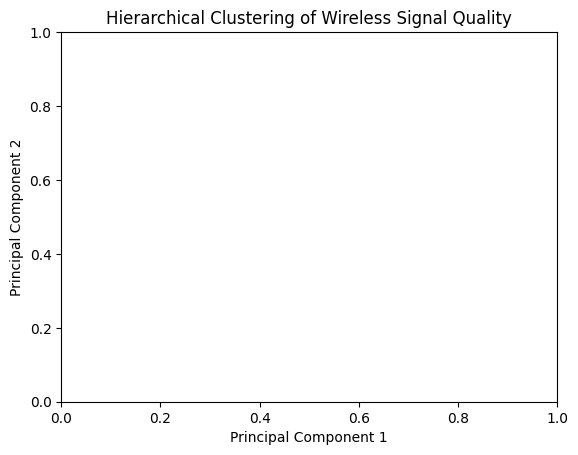

In [23]:
plt.title(
    "Hierarchical Clustering of Wireless Signal Quality"
)


plt.xlabel(
    "Principal Component 1"
)


plt.ylabel(
    "Principal Component 2"
    )


plt.show()

